# Datenvisualisierung mit Matplotlib

![Matplotlib](https://raw.githubusercontent.com/matplotlib/matplotlib/0b5940f544c5715220a9f3d57c971d3fc4073b64/doc/_static/logo2.svg)

Um mit Matplotlib arbeiten zu können, muss die Bibliothek erst einmal importiert werden. 
Damit wir nicht so viel tippen müssen, geben wir ihr den kürzeren Namen `plt`.

In [1]:
import matplotlib.pyplot as plt

Folgende Zeilen sind nur hier wichtig und sollen **nicht** übernommen werden.

In [2]:
from IPython.display import Image

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["font.size"] = 16
plt.rcParams["lines.linewidth"] = 2

Außerdem brauchen wir der Einfachheit halber ein paar Funktionen aus `numpy`, die dir schon bekannt vorkommen sollten.

In [3]:
import numpy as np

x = np.linspace(0, 1)  # gibt 50 Zahlen in gleichmäßigem Abstand von 0–1

Zuerst ein einfaches Beispiel mit $f(x)=x^2$.
Um den Text-Output in diesem Notebook zu unterdrücken, schreiben wir manchmal ein `;` hinter die letzte Zeile.

Im Folgenden verwenden wir die objekt-orientierte Schreibweise von `matplotlib`, die mehr Möglichkeiten und Freiheiten bietet.
Diese rufst du mit

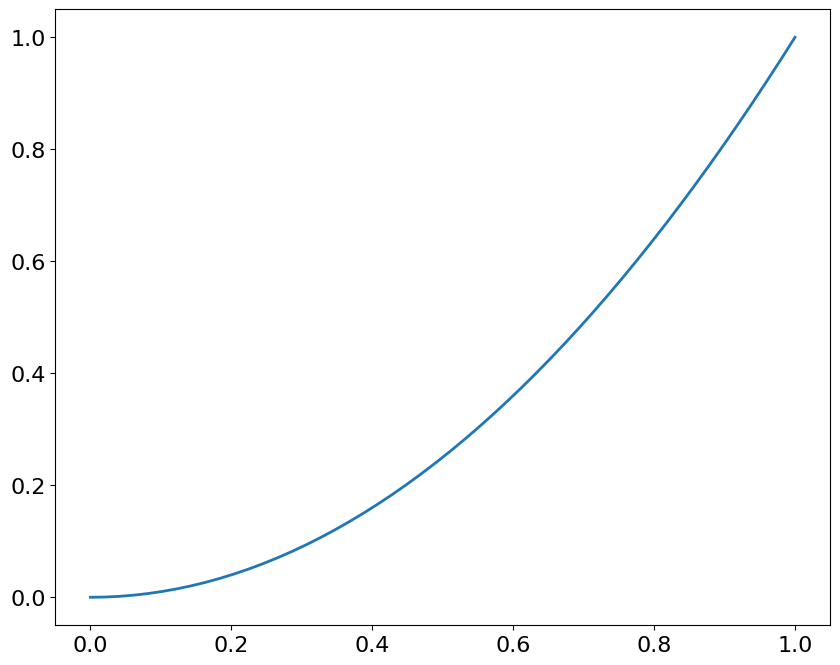

In [4]:
fig, ax = plt.subplots()

ax.plot(x, x**2);

auf.
Du hast dann ein Objekt figure `fig` und ein Objekt axes `ax`, mit denen du interagieren und die Einstellungen im plot vornehmen kannst.

Das Objekt `figure` ist dabei die gesamte Abbildung, auf der sich Axen, labels und Text befinden können.
Die einzelnen `axes` Objekte sind die jeweiligen Koordinatensysteme, in die man die entsprechenden Daten plottet.
Mit diesen können auch Informationen über die Einheiten und Darstellung mit den Achsen definiert werden.

Anderes Beispiel: $\sin(t)$ mit verschiedenen Stilen. Vorsicht, die Funktionen und $\pi$ sind Bestandteil von `numpy`.

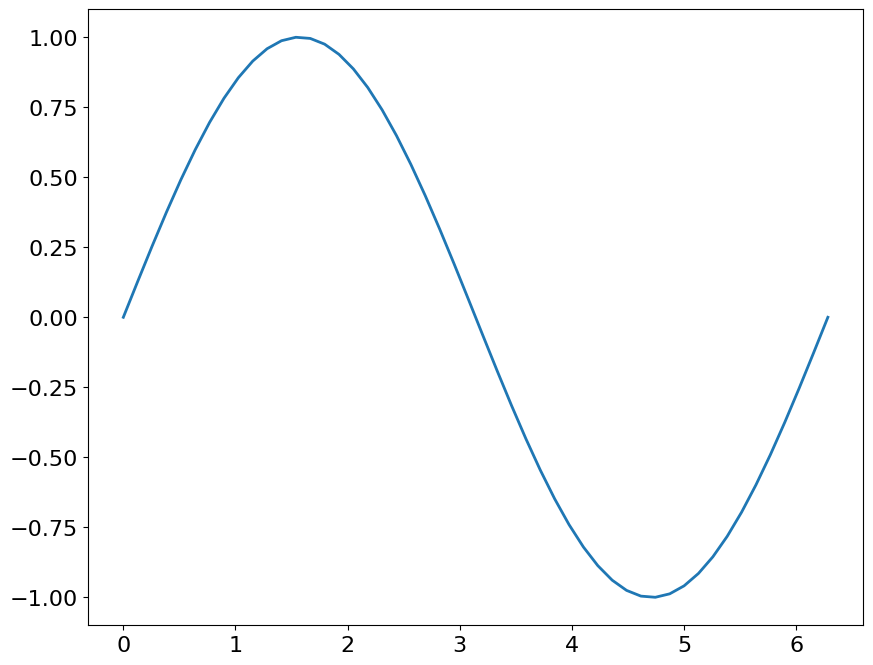

In [5]:
t = np.linspace(0, 2 * np.pi)

fig, ax = plt.subplots()
ax.plot(t, np.sin(t));

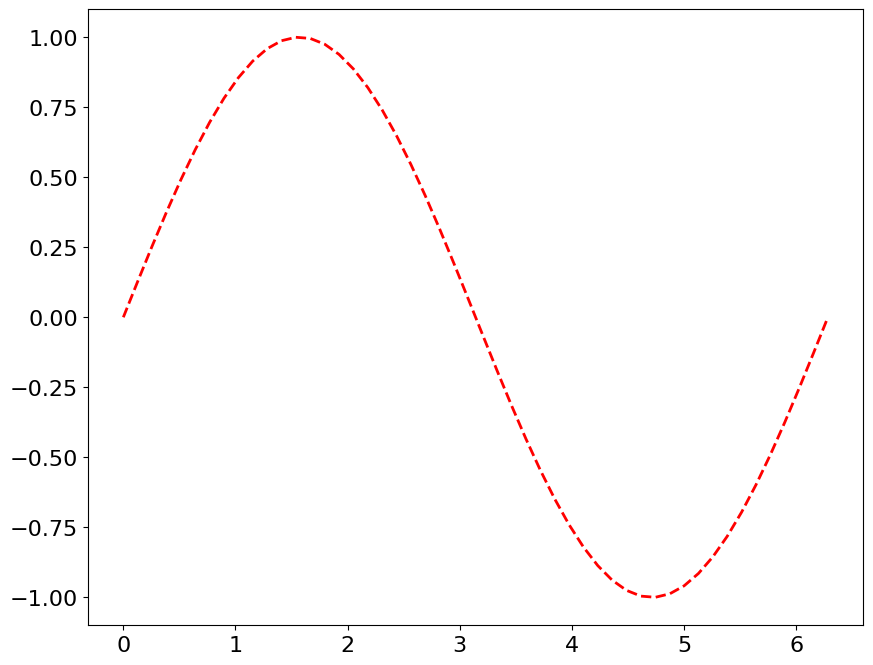

In [6]:
fig, ax = plt.subplots()
ax.plot(t, np.sin(t), "r--");

Mit `ax.cla()` entfernen wir alles, was wir vorher in das Achsenobjekt geschrieben haben.

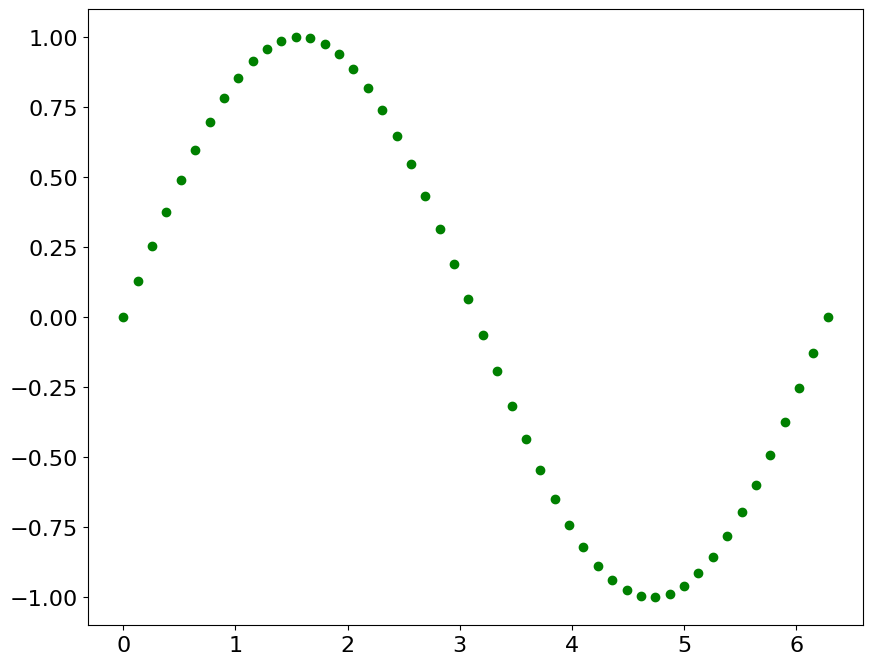

In [7]:
ax.cla()
ax.plot(t, np.sin(t), "go")
fig

Tabelle mit einigen Farben und Stilen: [matplotlib.axes.Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)

Tabellen mit allen Farben und Stilen:
- [Marker](https://matplotlib.org/stable/gallery/lines_bars_and_markers/marker_reference.html#sphx-glr-gallery-lines-bars-and-markers-marker-reference-py)
- [Linienstile](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html#sphx-glr-gallery-lines-bars-and-markers-linestyles-py)
- [Farben](https://matplotlib.org/stable/gallery/color/named_colors.html)

Der Vorteil ist nun, dass du z.B. mehrere Objekte `fig` und `ax` parallel benutzen und nachträglich wieder auf das vorherige zugreifen kannst.

Du kannst so auch im Nachhinein noch Dinge verändern und trotzdem die andere `figure` unverändert lassen.

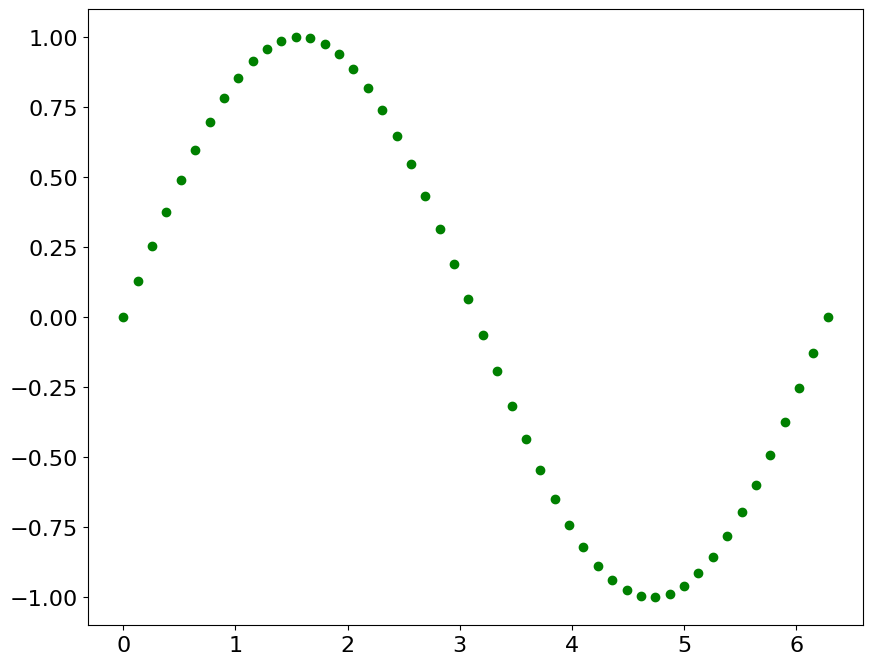

In [8]:
fig

Neue Grenzen setzen mit `set_xlim(a, b)` und `set_ylim(a, b)`

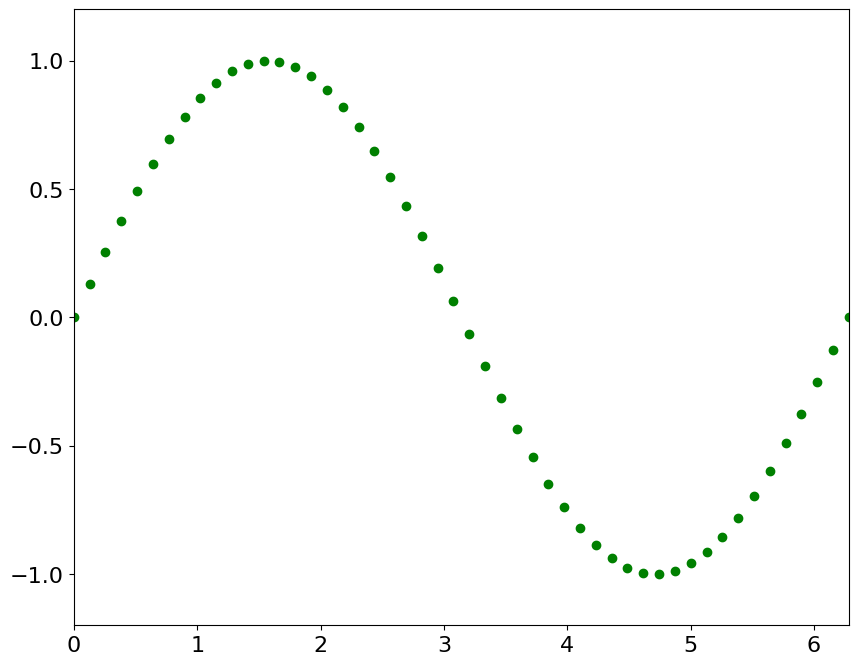

In [9]:
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-1.2, 1.2)
fig

## Es fehlt noch etwas...

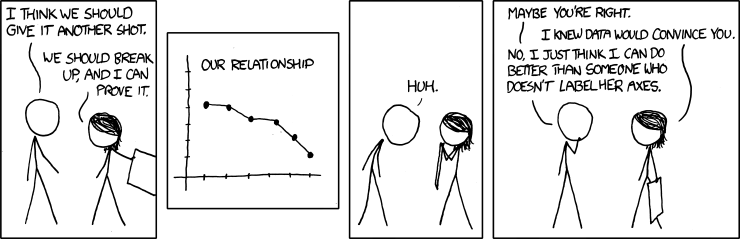

In [10]:
# https://imgs.xkcd.com/comics/convincing.png
Image(filename="images/xkcd-convincing.png")

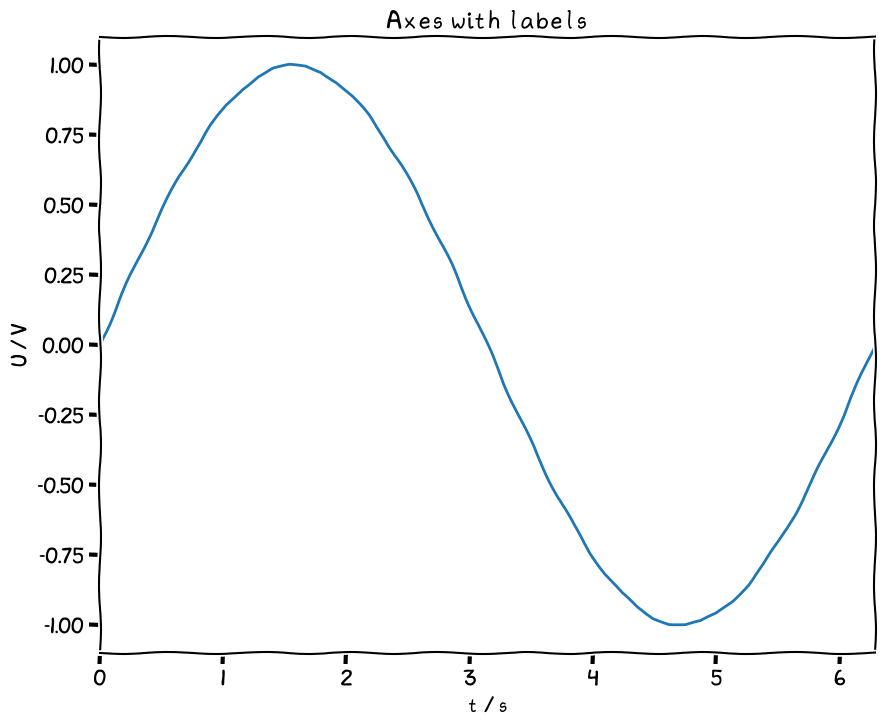

In [11]:
with plt.xkcd():
    fig, ax = plt.subplots()

    ax.set_title("Axes with labels")
    ax.plot(t, np.sin(t))
    ax.set_xlabel("t / s")
    ax.set_ylabel("U / V")
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlim(0, 2 * np.pi);

## Einheiten in Achsenbeschriftungen werden weg dividiert:
Achsenbeschriftungen können mit LaTeX-Code erstellt werden → LaTeX-Kurs in der nächsten Woche.

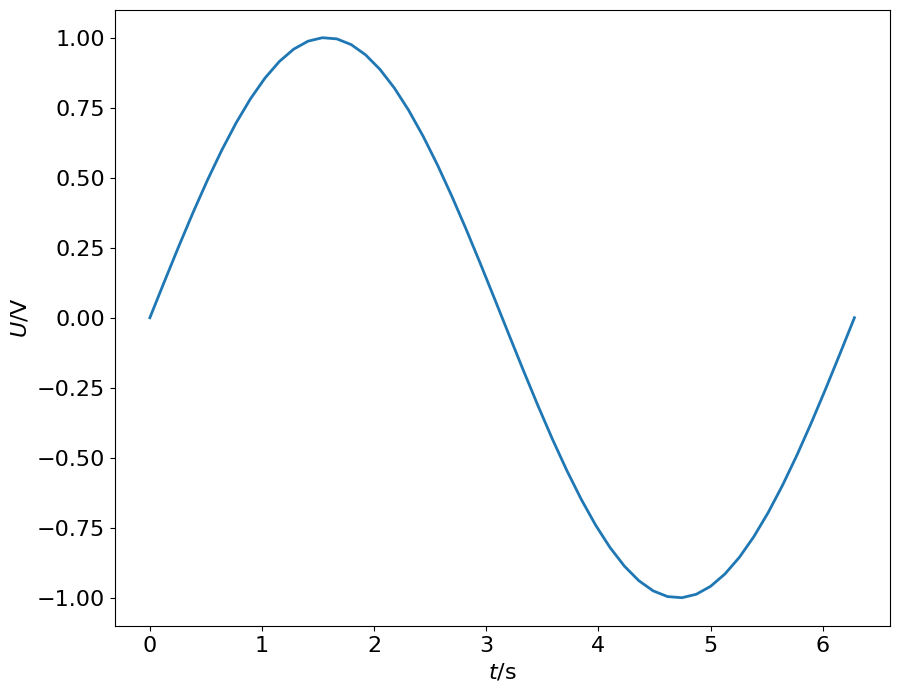

In [12]:
fig, ax = plt.subplots()

ax.plot(t, np.sin(t))
ax.set_xlabel(r"$t / \mathrm{s}$")
ax.set_ylabel(r"$U / \mathrm{V}$");

# ax.plot(t, np.sin(t))
# ax.set_xlabel(r'$t / \mathrm{s}$')
# ax.set_ylabel(r'$U \,/\, \mathrm{V}$');  # Spaces sind Geschmacksfrage

Mehr zu Einheiten gibt es im LaTeX-Kurs.

Als eine alternative Schreibweise für die verschiedenen Einstellungen der `axes` kann man auch

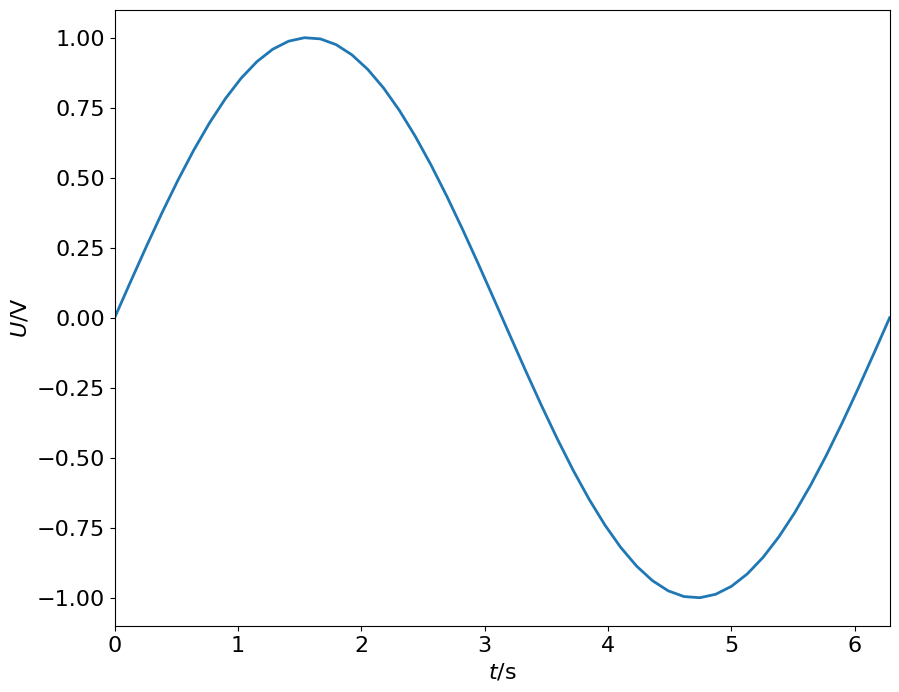

In [13]:
ax.set(
    xlim=(0, 2 * np.pi),
    xlabel=r"$t / \mathrm{s}$",
    ylabel=r"$U / \mathrm{V}$",
)
fig

verwenden.
Dabei können alle notwendigen Optionen der `axes` dann gebündelt hingeschrieben werden, was in der Übersichtlichkeit helfen kann.

## Legende
Legenden für Objekte, die ein `label` tragen.

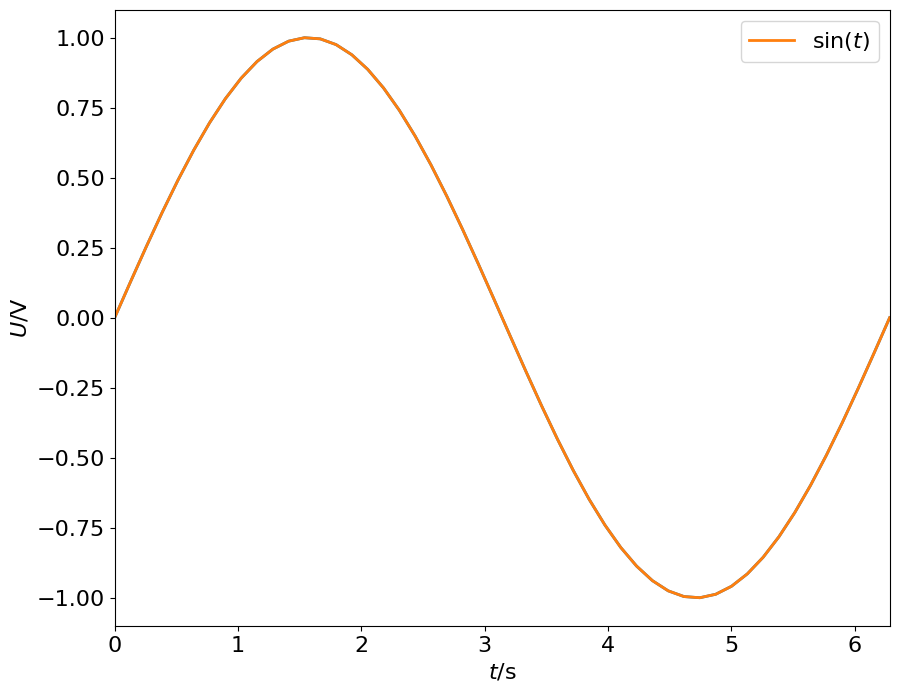

In [14]:
ax.plot(t, np.sin(t), label=r"$\sin(t)$")
ax.legend()
# ax.legend(loc="lower left")
# ax.legend(loc="best")
fig

# fig.legend()  # kann helfen, wenn man mehr als eine Achse und Platz für die Beschriftung an der Außenseite hat
# fig

Seit matplotlib 2.0.2 ist `loc=best` standardmäßig eingestellt.

Andere mögliche Orte für die Legende findest du [in der Dokumentation](https://matplotlib.org/stable/api/legend_api.html).

### Gitter
Mit `grid()` wird ein Gitter erstellt:

Hier wird auch der Vorteil der objekt-orientierten Schreibweise deutlich. Wir müssen keinen neuen plot erstellen, sondern können dem in `fig` hinterlegten neue Eigenschaften hinzufügen.
Andere mögliche Orte für die Legende findest du hier:
https://matplotlib.org/api/legend_api.html.

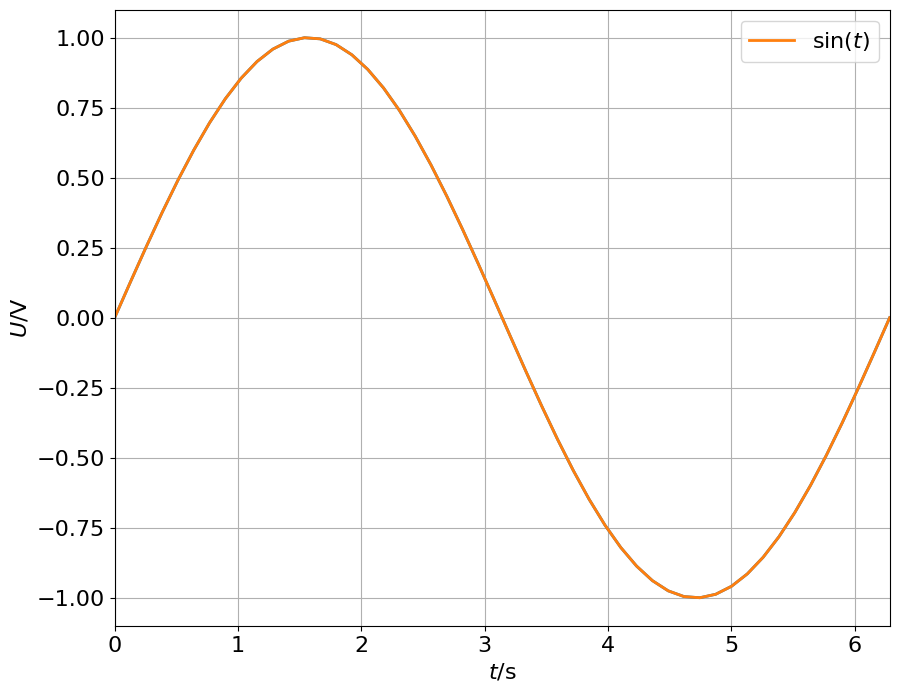

In [15]:
ax.grid()
# ax.grid(visible=None)
fig

# Achtung: Unterschied ax.grid() und ax.grid(True) bei mehrfachem Ausführen.
# Nur in Notebooks relevant, da Zellen potentiell mehrfach ausgeführt werden.
# Doku: If visible is None and there are no kwargs, this toggles the visibility of the lines.

## Laden von Daten

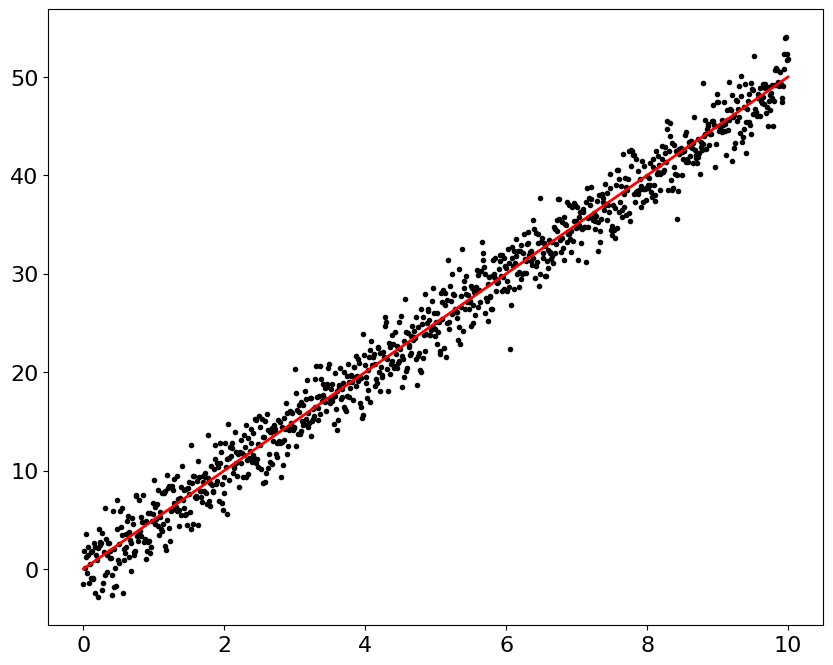

In [16]:
x, y = np.genfromtxt("data/example_data_linear.txt", unpack=True)

fig, ax = plt.subplots()
ax.plot(x, y, "k.")

t = np.linspace(0, 10)
ax.plot(t, 5 * t, "r-");

## Auslagern in ein Skript
Speicher den folgenden Code in eine Textdatei `plot.py` ab.

Öffne ein Terminal und starte das `python`-script mit:
    
    python plot.py

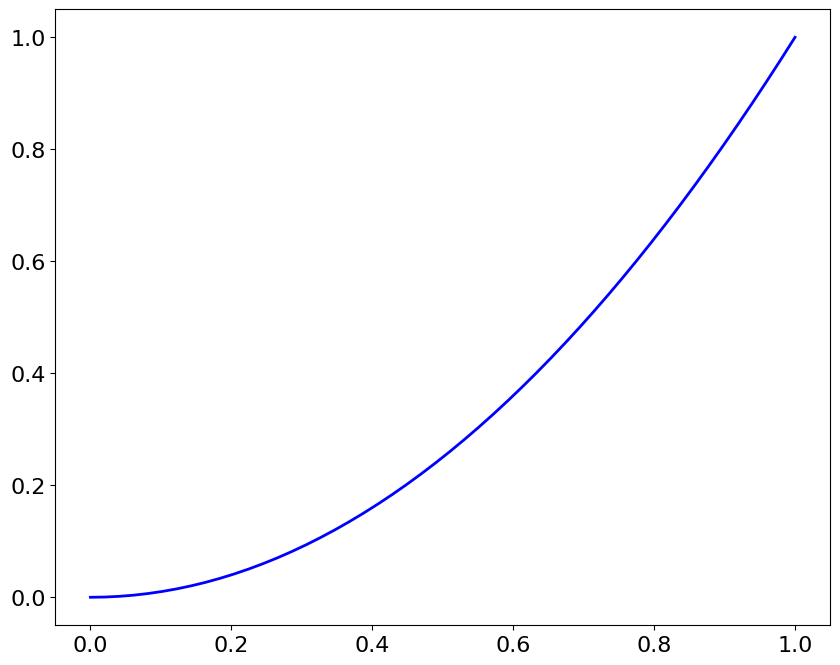

In [17]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1)
fig, ax = plt.subplots()

ax.plot(x, x**2, "b-")
fig.savefig("plot.pdf")

Mit `savefig` speichert man die Abbildung. Dies ist eine Funktion der `figure` und nicht der `axes`.

In diesem Fall sollte die Datei `plot.pdf` erstellt worden sein.

Es gibt viele Ausgabeformate: `pdf`, `png`, `svg`, LaTeX, ...

Um mehrere Plots in einem script erstellen und speichern zu können, kann man `ax.cla()` verwenden.
Der Befehl leert die aktuell aktiv genutzte `axes`-Umgebung und steht für `clear axis`.

Der Befehl `fig.clf()` leert die gesamte `figure` und man muss erst ein neues Objekt `ax` erstellen (z.B. mit `fig.add_subplots()`), bevor man wieder etwas plotten kann.

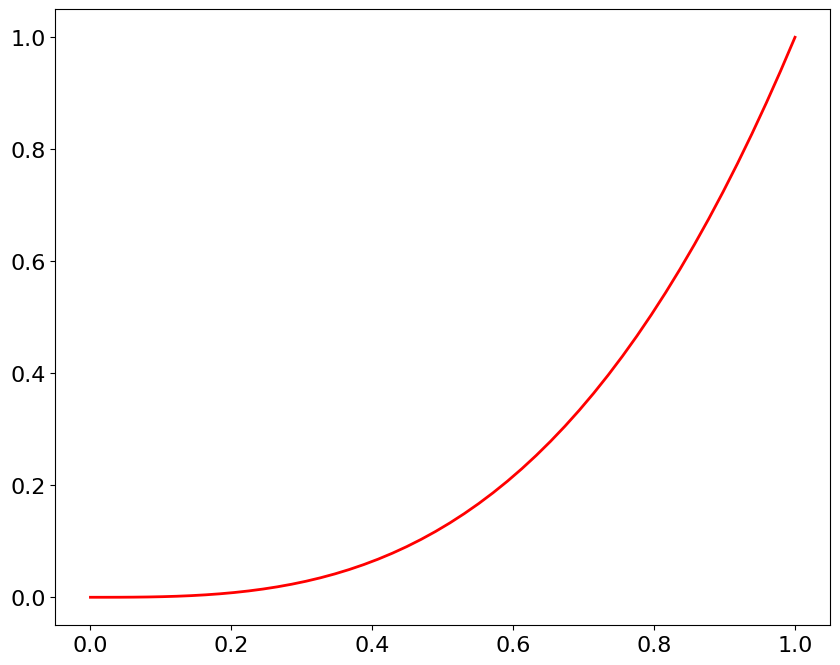

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1)

### Plot 1
fig, ax = plt.subplots()

ax.plot(x, x**2, "b-", label="Plot 1")
ax.legend()
fig.savefig("plot_1.pdf")

### Plot 2
ax.cla()

ax.plot(x, x**3, "r-")
fig.savefig("plot_2.pdf");

Alternativ kann man auch mehrere `fig` und `axes` Objekte parallel nutzen:

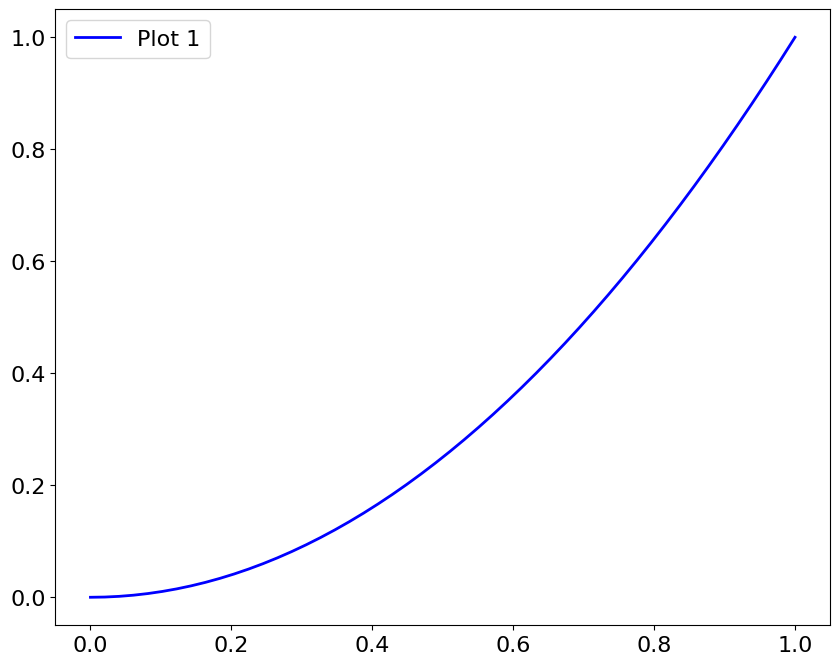

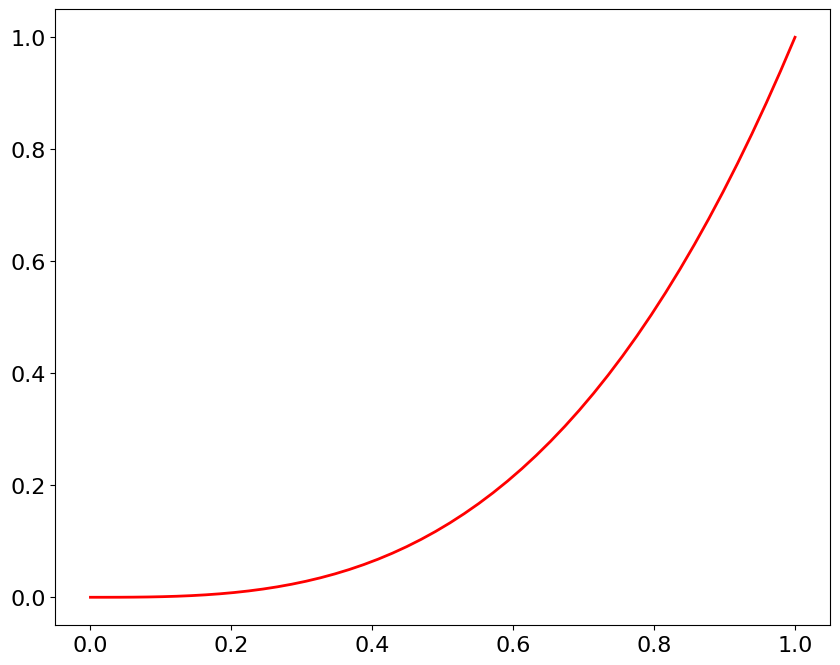

In [19]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1)

### Plot 1
fig1, ax1 = plt.subplots()

ax1.plot(x, x**2, "b-", label="Plot 1")
ax1.legend()
fig1.savefig("plot_1.pdf")

### Plot 2
fig2, ax2 = plt.subplots()

ax2.plot(x, x**3, "r-")
fig2.savefig("plot_2.pdf");

## Komplexere Abbildungen
Natürlich kann man mehrere Linien in einen Plot packen:

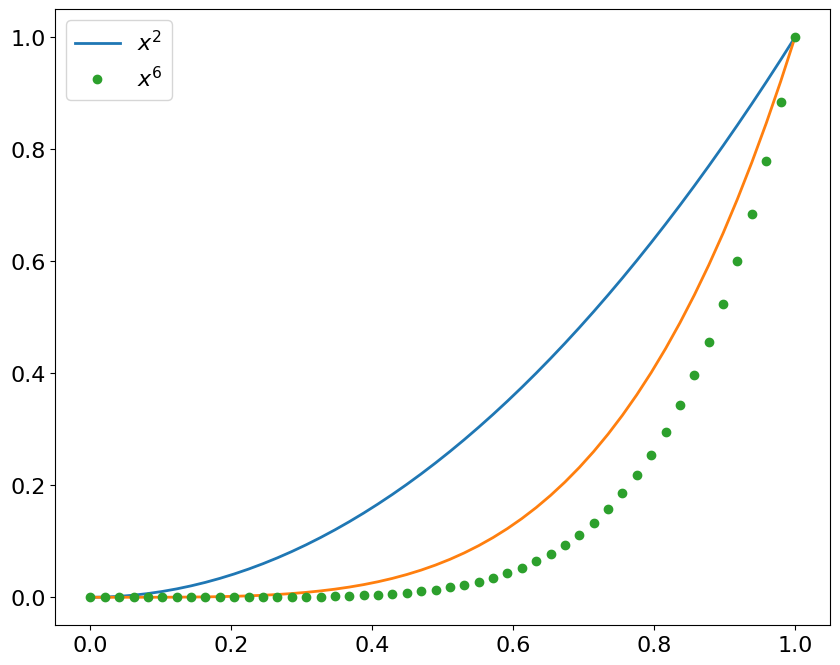

In [20]:
x = np.linspace(0, 1)

ax.cla()

ax.plot(x, x**2, label=r"$x^2$")
ax.plot(x, x**4)
ax.plot(x, x**6, "o", label=r"$x^6$")

ax.legend()
fig

Es werden nur die Plots in der Legende angezeigt, die ein Label haben.

### Mehrere Plots in einer Grafik
Man kann auch mehrere Plots in ein Bild packen:

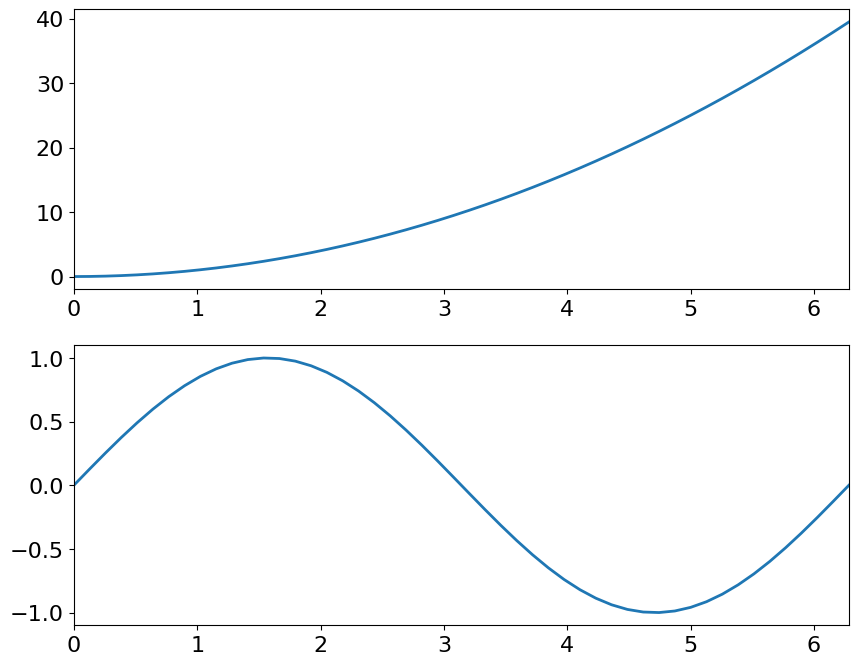

In [21]:
x = np.linspace(0, 2 * np.pi)

# rows, #columns, #position for add_subplot
fig, (ax1, ax2) = plt.subplots(2, 1)
# ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(x, x**2)
ax1.set_xlim(0, 2 * np.pi)

# ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(x, np.sin(x))
ax2.set_xlim(0, 2 * np.pi);

Dies führt manchmal zu Spacing-Problemen und Teilen, die sich überschneiden.

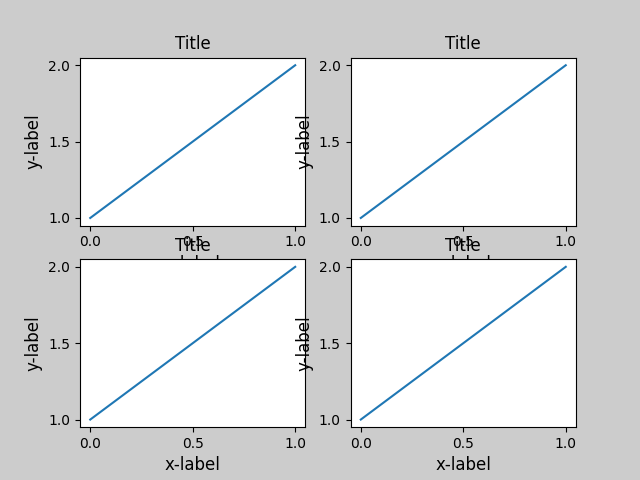

In [22]:
# https://matplotlib.org/stable/_images/sphx_glr_tight_layout_guide_003.png
Image(filename="images/tight_layout_guide.png")

Lösung: `layout="constrained"`

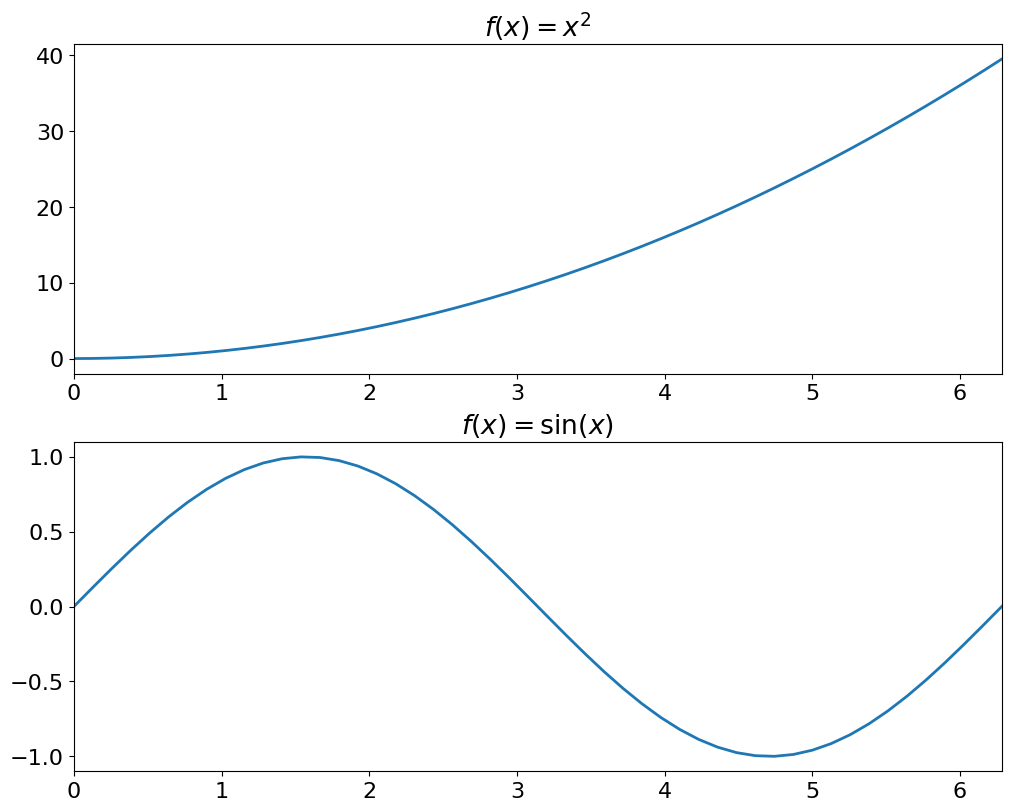

In [23]:
x = np.linspace(0, 2 * np.pi)

# Anzahl Zeile, Anzahl Spalten
fig, (ax1, ax2) = plt.subplots(2, 1, layout="constrained")

ax1.plot(x, x**2)
ax1.set_xlim(0, 2 * np.pi)
ax1.set_title(r"$f(x)=x^2$")

ax2.plot(x, np.sin(x))
ax2.set_xlim(0, 2 * np.pi)
ax2.set_title(r"$f(x)=\sin(x)$");

### Plot im Plot:

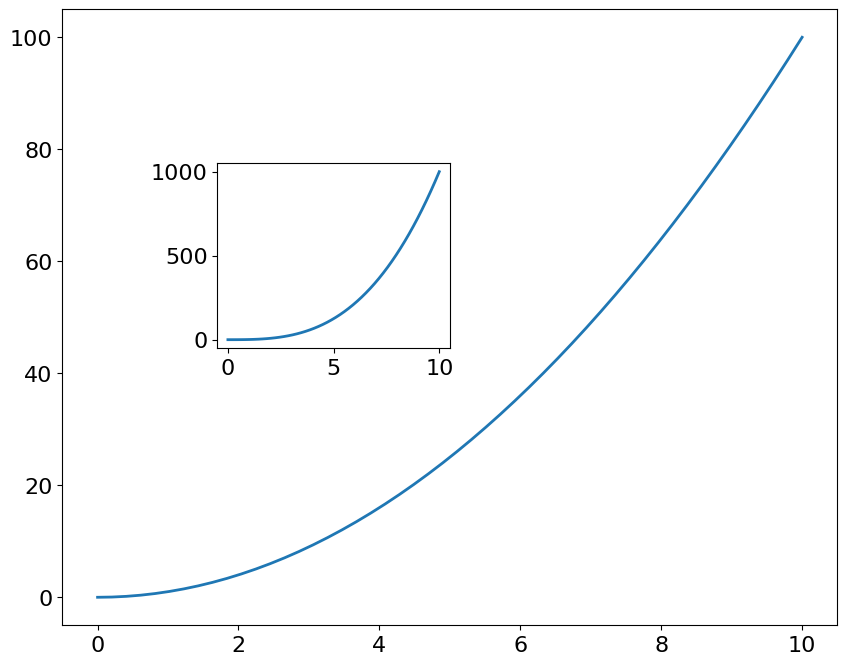

In [24]:
x = np.linspace(0, 10)

fig, ax = plt.subplots()
ax.plot(x, x**2)

# Koordinaten relativ zum Plot (0,0) links unten (1,1) rechts oben
# [x-location, y-location, x-length, y-length]
subax1 = ax.inset_axes([0.2, 0.45, 0.3, 0.3])

subax1.plot(x, x**3);

### Plots mit Fehlerbalken
Sehr häufig werden im Praktikum Plots mit Fehlerbalken benötigt, hier erzeugen wir einfach zufällige Fehlerbalken:

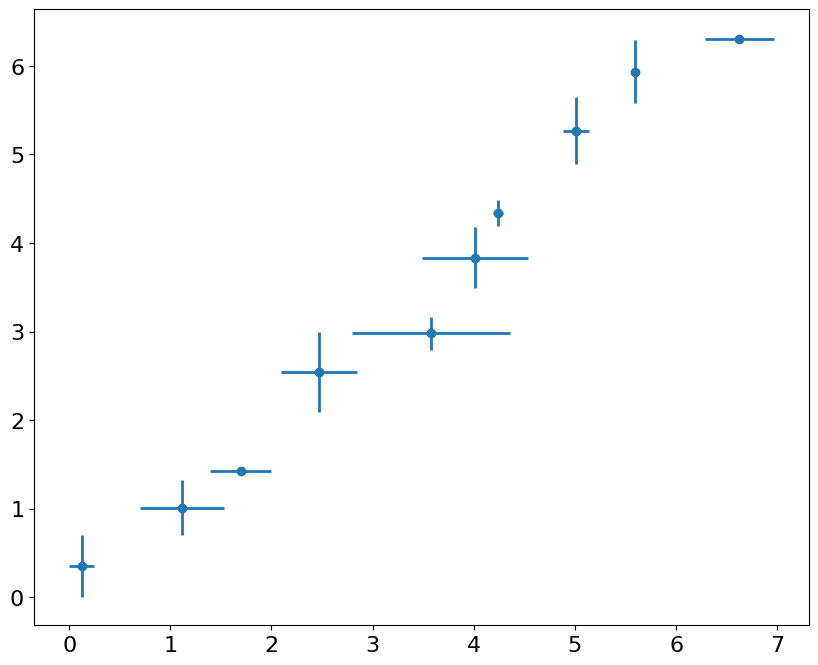

In [25]:
x = np.linspace(0, 2 * np.pi, 10)

rng = np.random.default_rng(42)

errX = 0.4 * abs(rng.standard_normal(len(x)))
errY = 0.4 * abs(rng.standard_normal(len(x)))

fig, ax = plt.subplots()

ax.errorbar(x + errX, x + errY, xerr=errX, yerr=errY, fmt="o");

### Achsen-Skalierung
Logarithmische (oder auch andere) Skalierung der Achsen ist auch möglich:

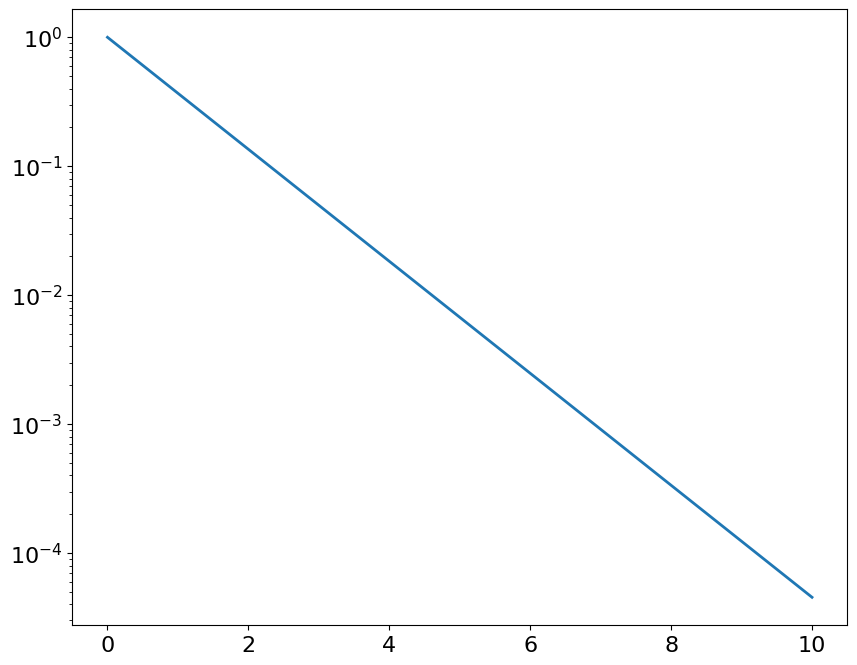

In [26]:
x = np.linspace(0, 10)

ax.cla()

ax.plot(x, np.exp(-x))
ax.set_yscale("log")
# ax.set_xscale('log')
fig

### Polarplot
Manchmal braucht man einfach einen Polarplot:

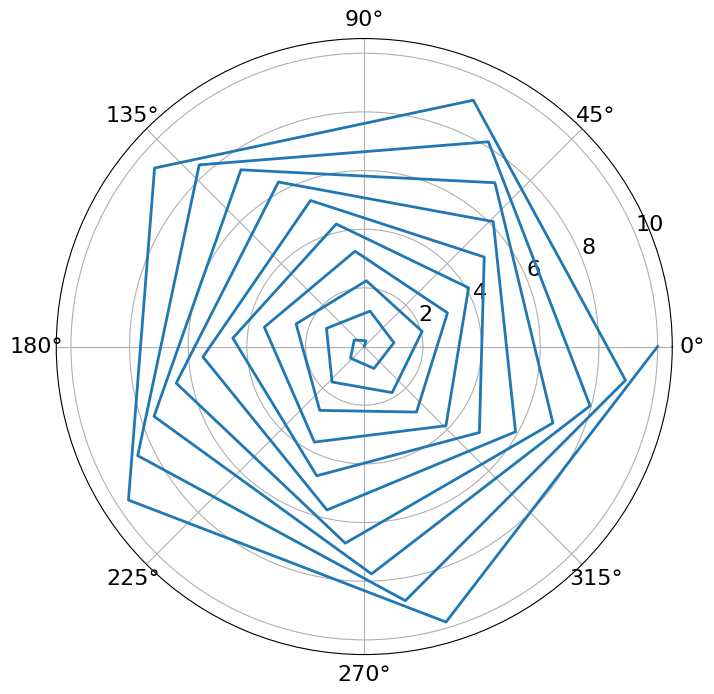

In [27]:
# r = np.linspace(0, 10, 1000)
r = np.linspace(0, 10, 50)
theta = 2 * np.pi * r


fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.plot(theta, r);

# Ticks
Man kann sehr viele Sachen mit Ticks machen…

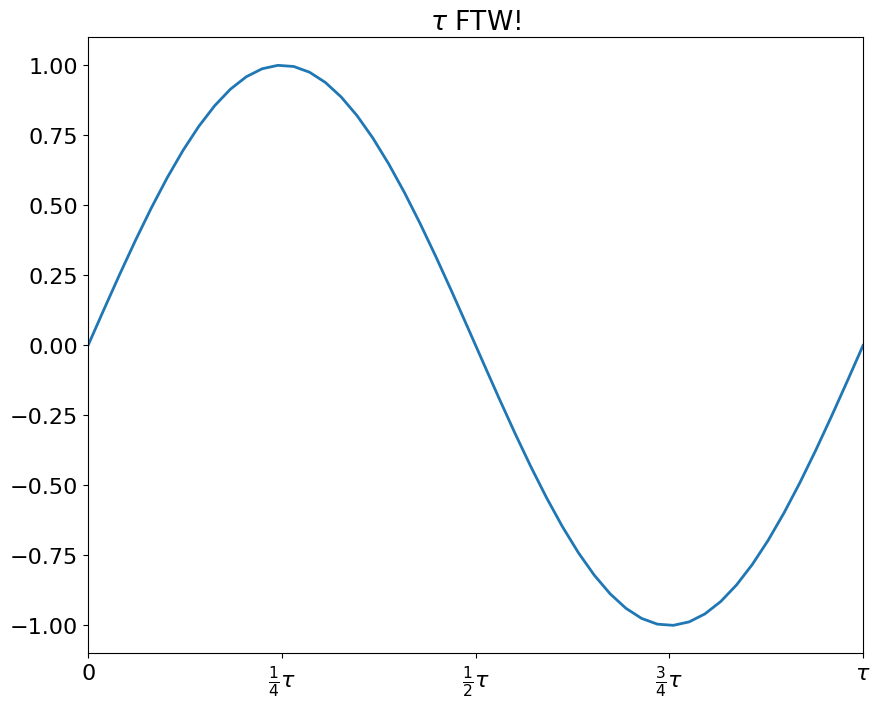

In [28]:
x = np.linspace(0, 2 * np.pi)

fig, ax = plt.subplots()

ax.plot(x, np.sin(x))
ax.set_xlim(0, 2 * np.pi)
# erste Liste: Tick-Positionen, zweite Liste: Tick-Beschriftung
ax.set_xticks(
    [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
    [
        r"$0$",
        r"$\frac{1}{4}\tau$",
        r"$\frac{1}{2}\tau$",
        r"$\frac{3}{4}\tau$",
        r"$\tau$",
    ],
)
ax.set_title(r"$\tau$ FTW!");

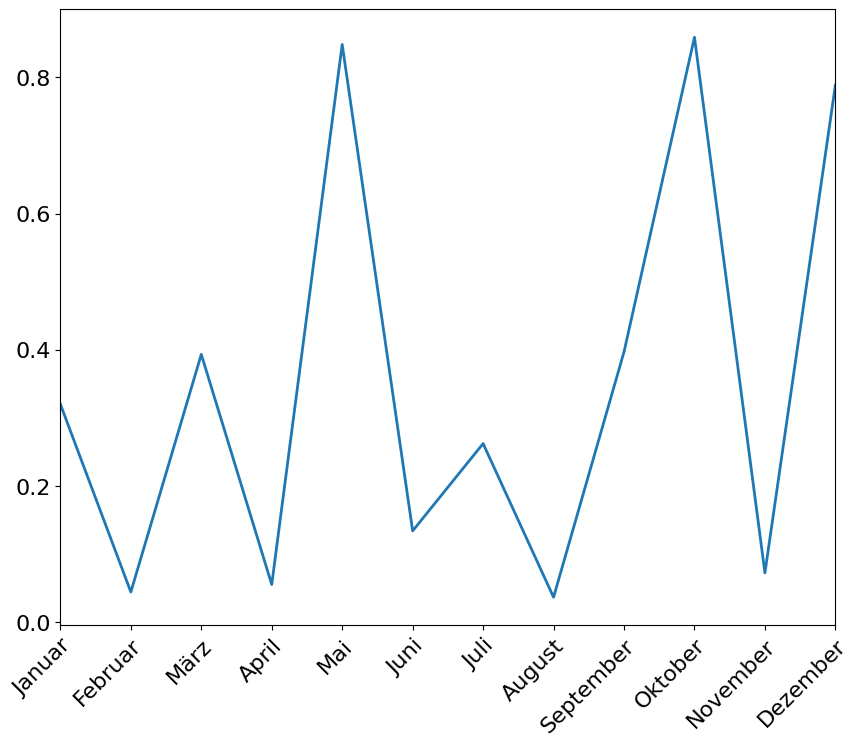

In [29]:
months = [
    "Januar",
    "Februar",
    "März",
    "April",
    "Mai",
    "Juni",
    "Juli",
    "August",
    "September",
    "Oktober",
    "November",
    "Dezember",
]

ax.cla()

ax.plot(np.arange(12), np.random.random(12))
ax.set_xticks(
    np.arange(12), months, rotation=45, rotation_mode="anchor", ha="right", va="top"
)
ax.set_xlim(0, 11)
fig

# Histogramme
Sehr häufig braucht man Histogramme.

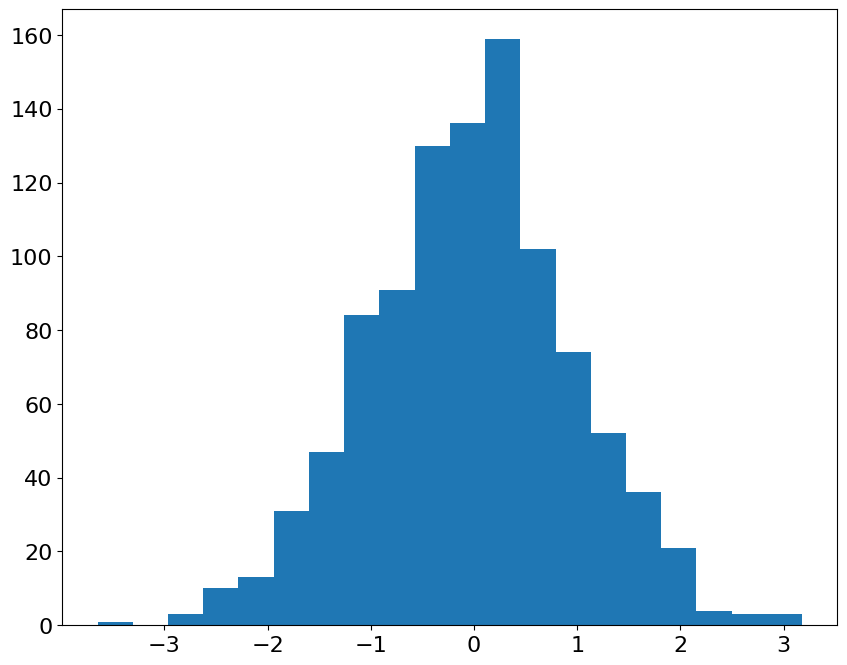

In [30]:
# Zufallsdaten generieren:
x = rng.normal(0, 1, 1000)

ax.cla()
ax.hist(x, bins=20)
# try histtype='step'
fig

# Nicht-Objektorientiertes Plotten
Bis jetzt haben wir die ausführliche, objektorientierte Variante von matplotlib benutzt.
Es gibt auch die "schnelle" Variante mit der einfacheren `pyplot`-Syntax. Wenn man viele Plots anlegt, ist der objekt-orientierte Ansatz für matplotlib allerdings meist besser geeignet.

Die Schreibweise `plt.plot` zeigen wir hier einmal, der Vollständig halber und damit auf Stack Overflow oder ähnlichen Seiten keine Verwirrung entsteht.
Es besteht eigentlich kein wirklicher Grund, diese Schreibweise aktiv zu nutzen.

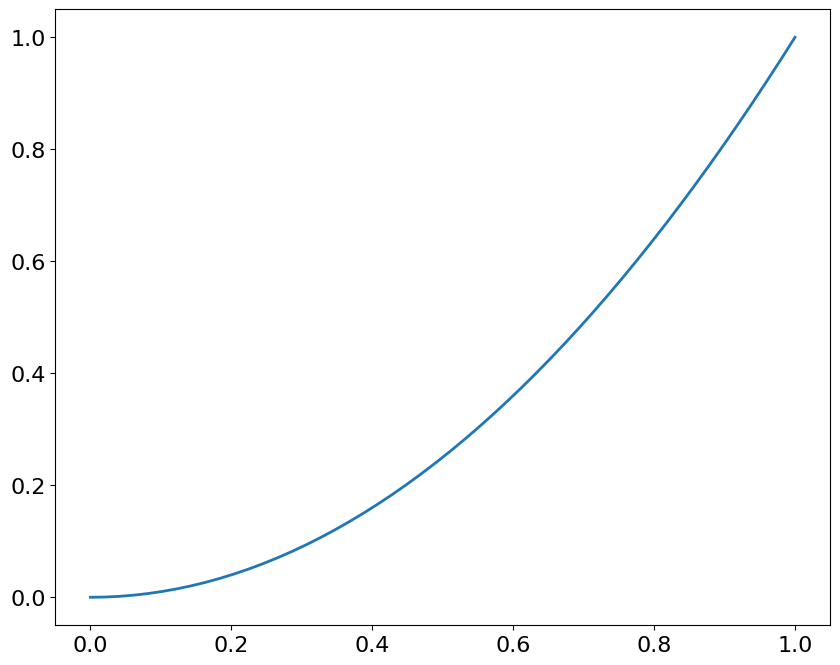

In [31]:
x = np.linspace(0, 1)  # gibt 50 Zahlen in gleichmäßigem Abstand von 0–1
plt.plot(x, x**2);
# Falls nicht interaktiv:
# plt.show()

# 3D Plots

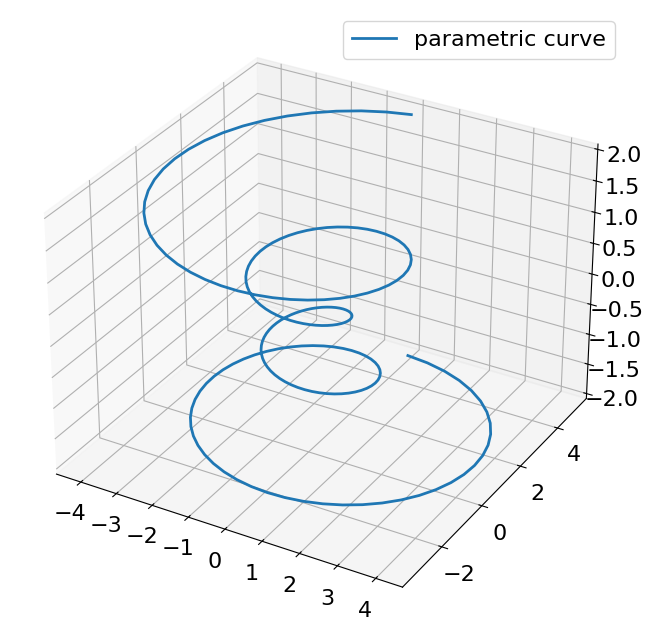

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

theta = np.linspace(-4 * np.pi, 4 * np.pi, 200)
z = np.linspace(-2, 2, 200)

r = z**2 + 1
x = r * np.sin(theta)
y = r * np.cos(theta)

ax.plot(x, y, z, label="parametric curve")
ax.legend();

Weitere Beispiele zum 3dim Plotten findest du hier:

https://matplotlib.org/stable/gallery/mplot3d/index.html

# LaTeX
Es ist auch möglich LaTeX für das Setzen aller Plot-Beschriftungen (d.h. Achsenbeschriftungen, Ticks, Legenden, usw.) zu verwenden. Schau dir dazu die "TeX in matplotlib" Folien, im LaTeX-Foliensatz an.

# Fortgeschrittene Plots

Manchmal möchte man komplexere Layouts für Plots haben. Hierbei ist `plt.subplots()` insofern eingeschränkt, als dass die Subplots nur auf einem $(N\times M)$-Gitter angeordnet werden können, bei dem jede Position auf dem Gitter mit einem einzelnen Plot besetzt wird. Hier beispielsweise $(2\times 3)$:

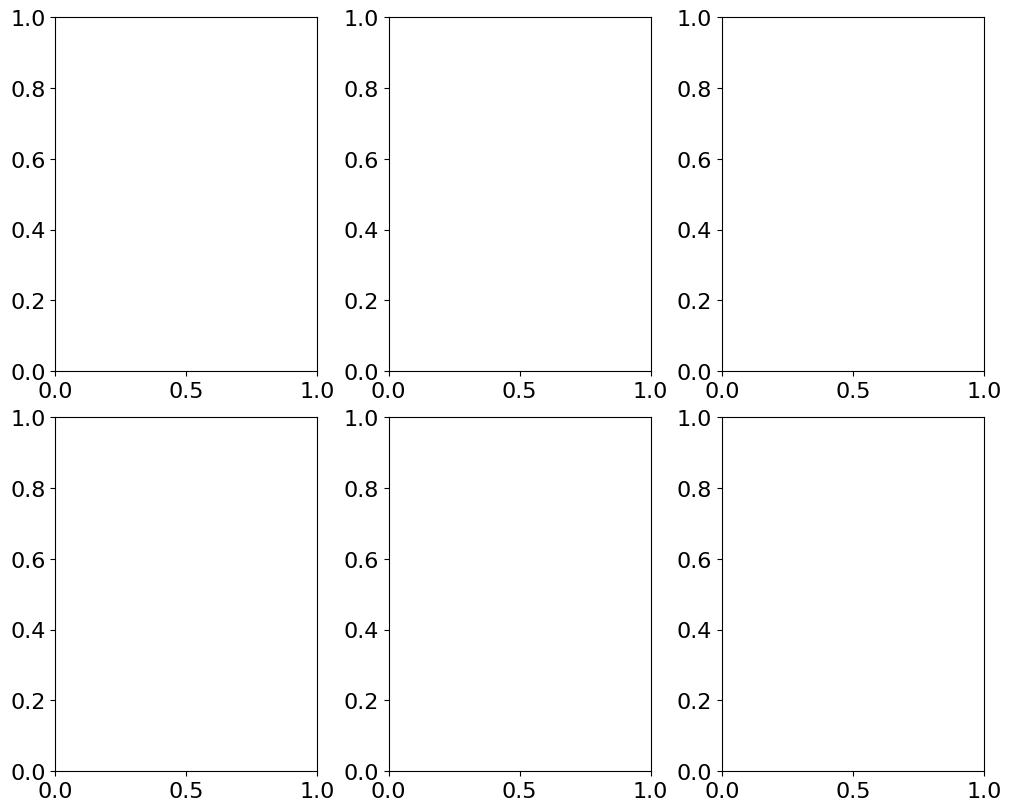

In [33]:
plt.subplots(2, 3, layout="constrained");

Eine Möglichkeit, komplexere Layouts zu erstellen bietet Matplotlib hierbei durch die Funktion `plt.subplot_mosaic()`. Diese ist eine einfach zu nutzende Hilfsfunktion für die `GridSpec`-Klasse, welche komplexe Anordnungen der Subplots ermöglicht. `plt.subplot_mosaic()` kann auf verschiedene Weisen verwendet werden:

## Layout über Strings

Hierbei gibt man über einen String die Positionen der Plots an. Dabei steht dann jedes Zeichen für einen (benannten) Plot und neue Zeilen erzeugen auch neue Zeilen im Plot.

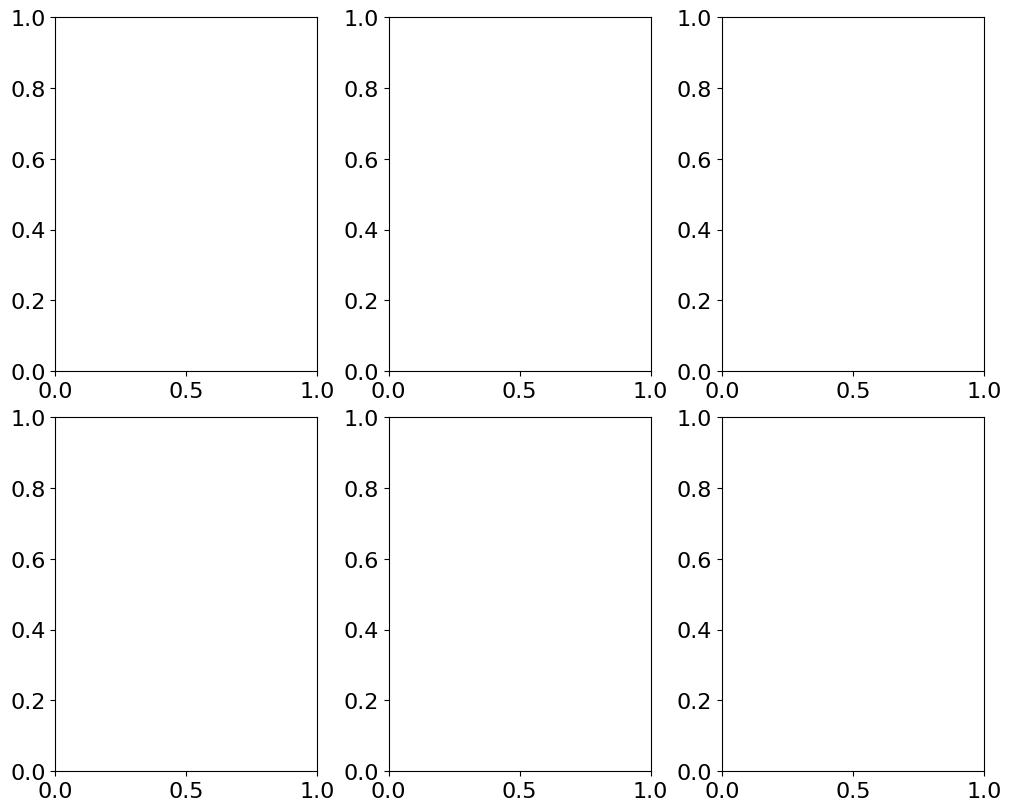

In [34]:
mosaic = """
    ABC
    DEF
"""

fig, ax = plt.subplot_mosaic(mosaic, layout="constrained");

Im Gegensatz zu den Abbildungen mit `plt.subplots()` gibt `plt.subplot_mosaic()` kein (mehrdimensionales) Array zurück, sondern ein Dictionary mit den Zeichen aus dem String als Keys und den Achsenobjekten als Values:

In [35]:
ax

{'A': <Axes: label='A'>,
 'B': <Axes: label='B'>,
 'C': <Axes: label='C'>,
 'D': <Axes: label='D'>,
 'E': <Axes: label='E'>,
 'F': <Axes: label='F'>}

Eine kompaktere Schreibweise für die Strings ist ebenfalls möglich:

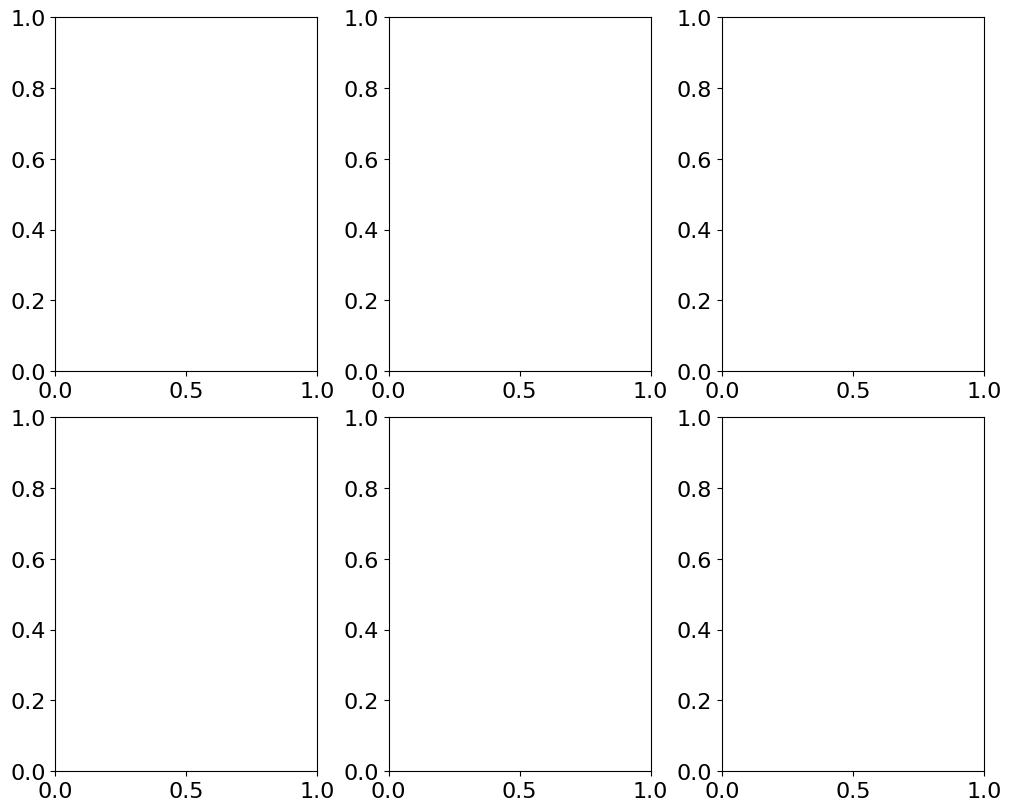

In [36]:
mosaic = "ABC;DEF"

fig, ax = plt.subplot_mosaic(mosaic, layout="constrained");

Hierbei werden neue Zeilen durch ein Semikolon `";"` angegeben.

## Layout über Listen von Strings

Layouts können auch über Listen von Strings angegeben werden. Das ist insbesondere dann nötig, wenn man Subplots mit mehr als einem Zeichen benennen möchte. Jede Zeile ist hierbei eine eigene Liste ("nested lists"):

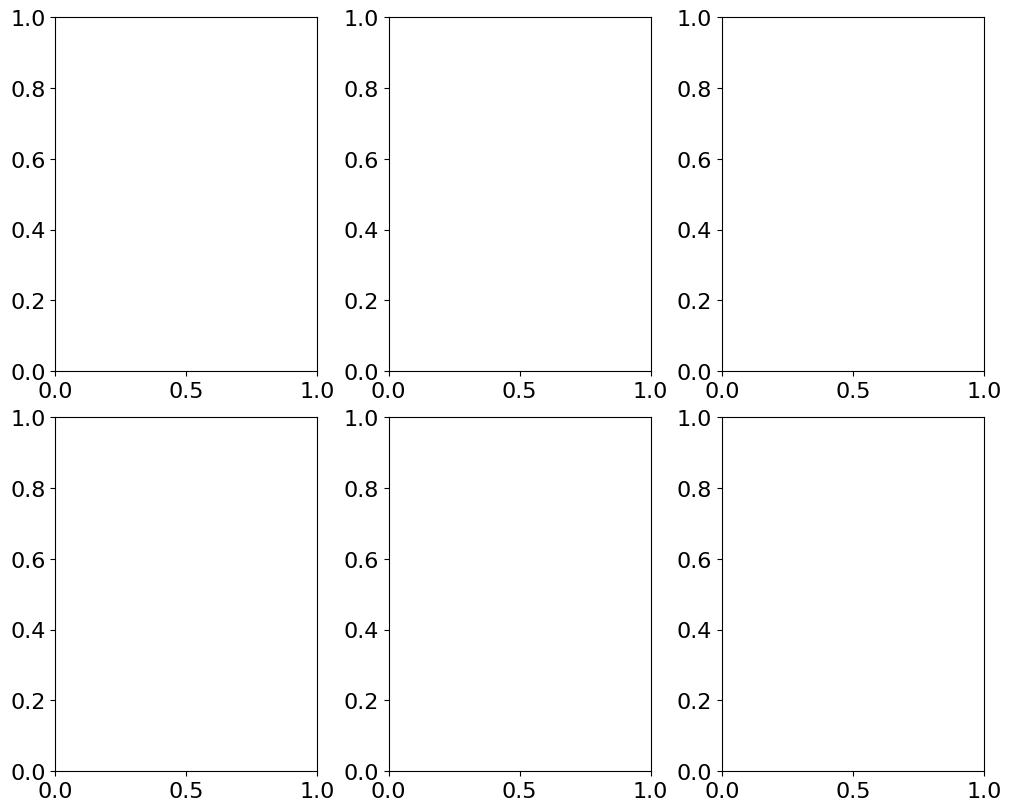

In [37]:
mosaic = [["Aa", "Bb", "Cc"], ["Dd", "Ee", "Ff"]]

plt.subplot_mosaic(mosaic, layout="constrained");

**Achtung**: Auch bei einer einzelnen Zeile muss diese in eine äußere Liste verschachtelt werden: `[["A", "B", "C"]]`

## Fortgeschrittene Layouts mit `plt.subplot_mosaic()`

Bisher haben wir immer nur das $(2\times 3)$-Layout nachgebaut, welches wir auch einfach mit `plt.subplots()` erzeugen können. Der Vorteil von `plt.subplot_mosaic()` liegt nun darin, dass wir Subplots auch über mehrere Zeilen oder Spalten ziehen können. Hierzu werden benachbarte Gitterpositionen einfach gleich benannt:

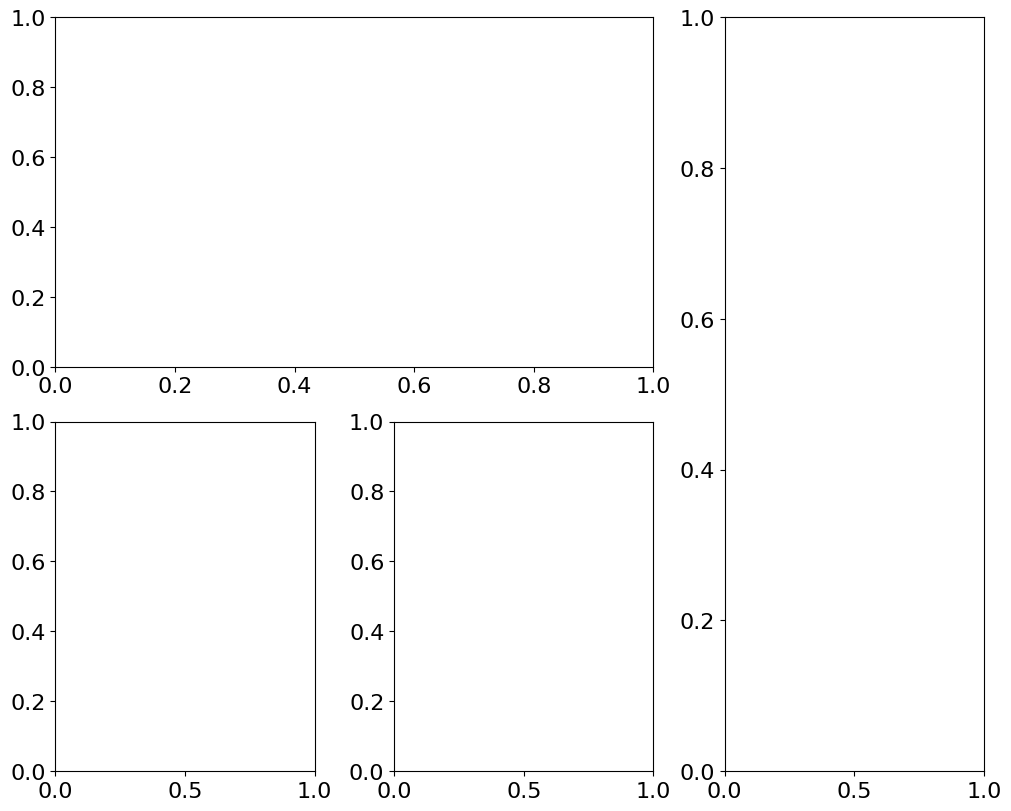

In [38]:
mosaic = """
    AAB
    CDB
"""

plt.subplot_mosaic(mosaic, layout="constrained");

Wir können aber auch noch mehr: Mit einem Punkt `"."` können wir Positionen markieren, an denen wir keine Plots haben wollen:

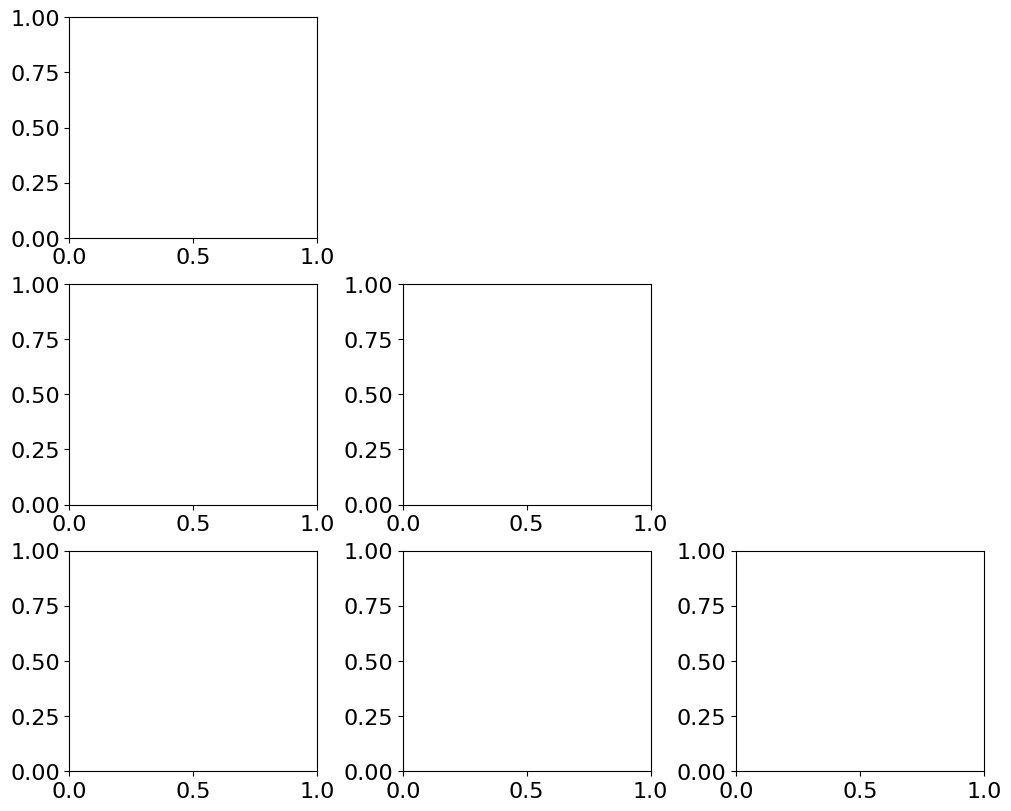

In [39]:
mosaic = """
    A..
    BC.
    DEF
"""

plt.subplot_mosaic(mosaic, layout="constrained");

Statt des Punktes kann auch ein beliebiges anderes Zeichen genutzt werden. Dazu wird beim Aufruf der Funktion das Keyword-Argument `empty_sentinel` übergeben:
Hier beispielsweise mit einem Sternchen `"*"`:

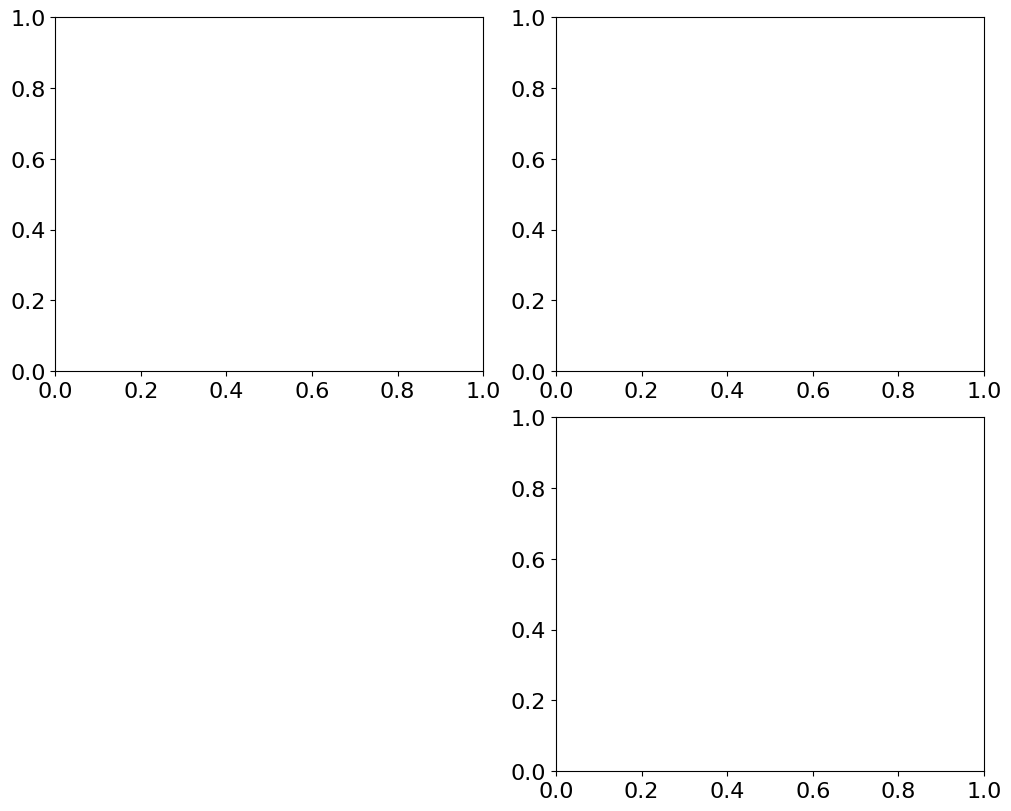

In [40]:
mosaic = """
    AB
    *C
"""

plt.subplot_mosaic(mosaic, layout="constrained", empty_sentinel="*");

Ein weiterer Vorteil von `plt.subplot_mosaic()` ist die Benennung der Achsen. Hier können wir unsere Subplots beispielsweise einfach mit Labels versehen:

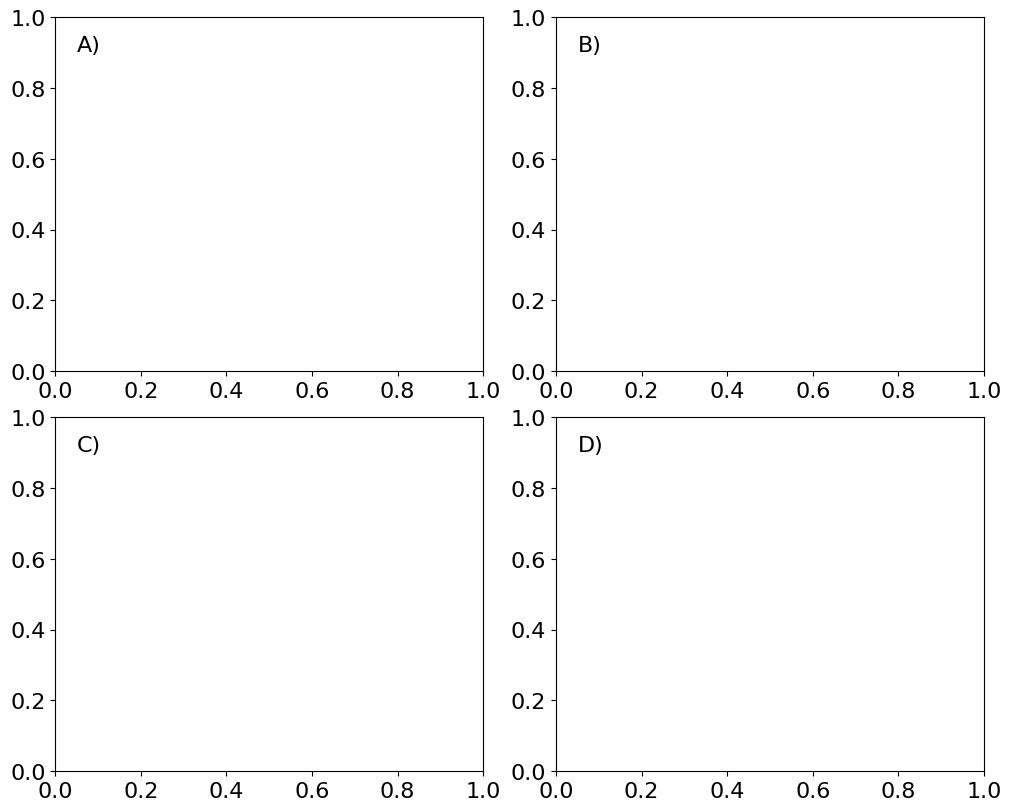

In [41]:
mosaic = [["A)", "B)"], ["C)", "D)"]]

fig, axs = plt.subplot_mosaic(mosaic, layout="constrained")

for ax in axs.values():
    anchor = ax.get_window_extent()

    ax.annotate(ax.get_label(), (0.05, 0.95), xycoords=anchor, va="top")

Hierbei nutzen wir die `ax.get_label()` Methode, um in der `ax.annotate()` Methode einen Text (unser Label) mit Ausrichtung oben ("vertical alignment", `va="top"`) an die Relativkoordinate $(0.05, 0.95)$ der Achse zu setzen. Die Zeile `anchor = ax.get_window_extent()` zusammen mit dem Keyword-Argument `xycoords=anchor` in `ax.annotate()` sorgt dafür, dass wir uns im Koordinatensystem der Achse befinden und nicht im Koordinatensystem des etwaigen Plotinhalts selbst.

## Parameter für einzelne Subplots

Wir können zusätzlich zu den bereits genannten Möglichkeiten von `plt.subplot_mosaic()` mittels des Keyword-Arguments `per_subplot_kw` auch Parameter für die einzelnen Subplots übergeben:

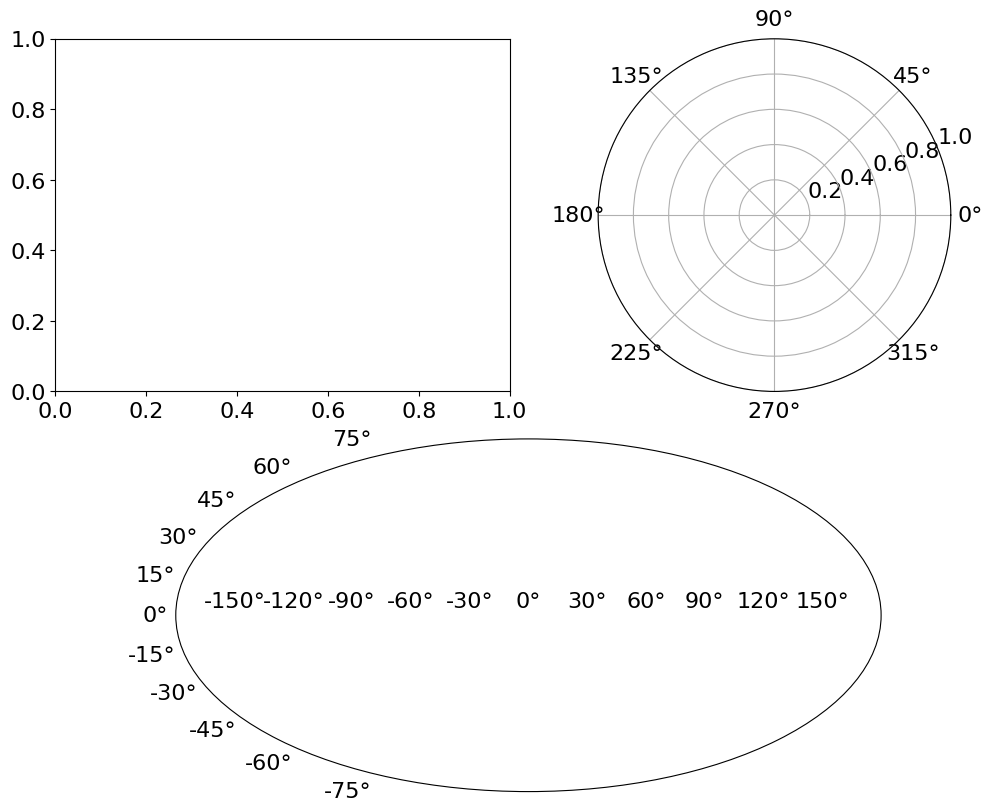

In [42]:
plt.subplot_mosaic(
    "AB;CC",
    per_subplot_kw={
        "B": {"projection": "polar"},
        "C": {"projection": "mollweide"},
    },
    layout="constrained",
);

`per_subplot_kw` erwartet hierbei ein Dictionary, bei dem die Achsennamen als Key und ein weiteres Dictionary als Value übergeben werden.

Weiterführende Informationen und Beispiele lassen sich in der Dokumentation zu [matplotlib.pyplot.subplot_mosaic](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot_mosaic.html) finden.